In [1]:
import os

os.environ["OPENAI_API_KEY"] = "sk-19fe6b9376f8473bab1defd0bde82559"

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="glm-5",
#     model="qwen3.5-plus",
    temperature=0,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

D:\Anaconda\envs\taidibei\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [3]:
import re
import pdfplumber
from langchain_core.documents import Document

def clean_text(text):
    text = re.sub(r'[ \t]+', ' ', text)  
    text = re.sub(r'\n{3,}', '\n\n', text)  
    return text.strip()

In [4]:
from langchain_community.document_loaders import PDFPlumberLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm

pdf_folder = r"示例数据\附件5：研报数据"
docs = []

for file_name in os.listdir(pdf_folder):
    file_path = os.path.join(pdf_folder, file_name)
    
    if os.path.isdir(file_path):
        
        for pdf_name in os.listdir(file_path):
            pdf_path = os.path.join(file_path, pdf_name)
            
            loader = PyMuPDFLoader(pdf_path)
            docs.extend(loader.load())

            
print(docs[0].page_content)
print("-"*100)
print(docs[0].metadata)
        
for doc in docs:
    doc.page_content = clean_text(doc.page_content)

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=1500, chunk_overlap=500
)

doc_splits = text_splitter.split_documents(docs)

请务必阅读正文后的重要声明部分 
 
1 
2025 年10 月29 日 
证券研究报告•2025 年三季报点评 
买入 （维持） 
 
当前价： 28.94 元 
华润三九（000999） 医药生物 
目标价： ——元（6 个月） 
内涵+外延双轮驱动，经营拐点已现 
投资要点 
西南证券研究院 
分析师：杜向阳 
执业证号：S1250520030002 
电话：021-68416017 
邮箱：duxy@swsc.com.cn 
联系人：王钰玮 
电话：021-68415819 
邮箱：wangyuwei@swsc.com.cn 
相对指数表现 
数据来源：聚源数据 
基础数据 
总股本(亿股) 
16.64 
流通A 股(亿股) 
16.63 
52 周内股价区间(元) 
27.30-37.35 
总市值(亿元) 
481.64 
总资产(亿元) 
386.98 
每股净资产(元) 
11.12 
相关研究 
1. 华润三九（000999）：业绩稳健增长，并
购整合持续推进  (2025-03-19) 
 
 事件：公司发布2025 年三季报。2025 年前三季度，公司实现营业收入219.9
亿元，同比+11.4%；归母净利润23.5 亿元，同比-20.5%；扣非归母净利润
为21.9 亿元，同比-20.6%。2025 年Q1/Q2/Q3 营收分别68.5/79.6/71.8 亿
元，分别同比-6%/+16.8%/+27.4%；归母净利润12.7/5.5/5.4 亿元，分别同
比-6.9%/-47.3%/-4.3%；扣非归母净利润12.2/4.8/4.9 亿元，分别同比
-8.3%/-51.1%/+10.1%，业绩符合预期。 
 内生业务环比增长，处方药逐步恢复。2025 年前三季度，公司实现营业收
入219.9 亿元，同比+11.4%；Q1/Q2/Q3 营收分别68.5/79.6/71.8 亿元，分
别同比-6%/+16.8%/+27.4%，其中内生业务三季度环比增长。1）CHC 领域，
呼吸品类受去年高基数与今年呼吸道疾病发病率回落影响，零售渠道自去年
年底起受政策影响呈阶段性调整。2）处方药已较好消化集采影响，逐步恢
复。天士力以处方药为核心，已完成百日融合，预计持续赋能。3）并表公
司昆药集团2025 前三季度营收显著下滑对公司收入产生影响。 


In [5]:
from langchain_milvus import Milvus
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 64,      # 视显存调整：16/32/64
        "show_progress_bar": True,
    },
)

vectorstore = Milvus.from_documents(
    documents=doc_splits,
    embedding=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="docs",
    drop_old=True,
)

C:\Users\cr\AppData\Local\Temp\ipykernel_40648\3288711727.py:5: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceBgeEmbeddings(
C:\Users\cr\AppData\Local\Temp\ipykernel_40648\3288711727.py:5: LangChainDeprecationWarning: `encode_kwargs['show_progress_bar']` was deprecated in LangChain 0.2.5 and will be removed in 1.0. Use the show_progress method on HuggingFaceBgeEmbeddings instead.
  embeddings = HuggingFaceBgeEmbeddings(


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
from langchain_milvus import Milvus
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embeddings = HuggingFaceBgeEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={"device": "cuda"},
    encode_kwargs={"normalize_embeddings": True},
)

vectorstore = Milvus(
    embedding_function=embeddings,
    connection_args={"host": "localhost", "port": "19530"},
    collection_name="docs",
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

texts = retriever.invoke("国家医保目录新增的中药产品有哪些")

for text in texts:
    print(text.page_content)
    print("-" * 50)

行业点评 
 
敬请参阅最后一页特别声明
扫码获取更多服务 
药物能够有效提升在患者中的渗透率。 
图表7：凭借商保，较高定价的药物能够实现患者渗透率的快速提升 
 
来源：insight，国金证券研究所 
中药经典名方申请较多，但政策鼓励创新方向明确。根据国家医保局25 年8 月公告，通过初步审查的中成药共23 种、
合计25 个产品。今日公示名单，最终入选7 个产品，包括4 个1 类新药以及3 个3 类新药。本次整体入选比例不高，
主要系经典名方申请较多，且多数未入选。通过初审名单中，共6 个1 类新药，最终入选4 个。12 个3 类中药，最终
入选3 个。6 个进口中药，无入选。1 个天然药物1.1 类，未入选。 
图表8：2025 年国家医保目录新增7 个中药产品 
 
来源：国家医保局，国金证券研究所 
投资建议 
西药：建议关注纳入新版医保目录创新药较多/品种重磅的恒瑞医药、百济神州、康方生物、科伦博泰、信达生物等，
以及大单品首次纳入医保的康诺亚（IL4 单抗）、特宝生物（长效生长激素）等。 
中成药：建议关注入选新版医保目录的中药产品放量潜力，如华润三九的益气清肺颗粒、以岭药业的芪防鼻通片、方
盛制药的养血祛风止痛颗粒、康缘药业的玉女煎颗粒/温阳解毒颗粒等。 
序号
公司
药品
2025年医保目录价格
2025年医保目录适应症
用法用量
注册分类
1
华润三九
益气清肺颗粒
13.60元(每袋装15g(相当
于饮片52g))
益气养阴，健脾和中，清热祛湿。适用于疫病后短期症状，
气阴两虚，脾虚失运，余邪未尽证，症见倦怠乏力、动后气
短、干咳少痰、咽喉不利、胃脘痞闷、纳呆便溏，舌淡或红
、少津，脉细数。
温水冲服。1次1袋，1
日2次。疗程14天。
中药3.2类
2
以岭药业
芪防鼻通片
--------------------------------------------------
行业点评 
 
敬请参阅最后一页特别声明
扫码获取更多服务 
 
凭借相关药物的医保准入，有望实现产品放量与市场份额的快速提升。本轮医保谈判中西药涉及的107 个品类，
合计116 款药物（部分同一品类有多家药企入选）。其中恒瑞医药合计11 款新药首次纳入医保目录，其次是阿斯
利康合计纳入4 款，正大天晴、科伦博泰、礼来制药、齐鲁制药、罗氏制药则分别成功纳入3 款药

In [6]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_pdf_file",
    "Search and return information from the internal knowledge base.",
) 

In [7]:
import pandas as pd
from sqlalchemy import create_engine
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit

engine = create_engine("sqlite:///example.db")

###
sheets = pd.read_excel(
    r"示例数据\附件2：财务报告\深交extract_result.xlsx",
    sheet_name=None,
    engine="openpyxl"
)
###

for sheet_name, df in sheets.items():
    table_name = sheet_name.strip().replace(" ", "_").replace("-", "_")
    df.to_sql(table_name, con=engine, if_exists="replace", index=False)

db = SQLDatabase.from_uri("sqlite:///example.db")
print(db.get_usable_table_names())

['balance', 'cash', 'core', 'income', 'other']


In [8]:
import os
import requests, pathlib
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI

from langchain.messages import AIMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

In [10]:
def merge_dict(a, b):
    a = a or {}
    b = b or {}
    out = dict(a)
    out.update(b)
    return out

def merge_list(a, b):
    return (a or []) + (b or [])

In [11]:
from typing_extensions import TypedDict, Required
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List, Dict, Any, Literal, Annotated
from pydantic import BaseModel, Field
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class SubTask(BaseModel):
    task_id: str
    type: Literal["sql", "rag", "synthesis", "clarify"]
    goal: str
    priority: int = Field(default=5, ge=1, le=10)
    depends_on: List[str] = Field(default_factory=list)
    status: Literal["pending", "ready", "running", "done", "failed"] = "pending"

class ParentState(MessagesState, total=False):
    query: Required[str]
        
    real_query: str

    route: Literal["sql", "rag", "hybrid", "clarify"]
    reason: str
    missing_slots: List[str] = []
        
    task_plan = List[dict]
    
    task_results: Annotated[Dict[str, dict], merge_dict]
    execution_trace: Annotated[List[dict], merge_list]

    final_answer: str
    summary: str
        
    sql_messages: Annotated[list[AnyMessage], add_messages]

In [12]:
def merge_query(state: ParentState):
    query = state["query"] or state["messages"][-1].content
    summary = state.get("summary", "")
    
    if summary == "":
        return {
        "real_query": query,
        }
    
    prompt = f"""
    
你是一个对话查询改写助手。你的任务是根据“历史对话摘要 summary”和“用户当前输入 query”，判断用户这一轮真正想问的问题，并输出一个完整、明确、可独立理解的 query。

请严格遵循以下规则：

1. 如果当前 query 本身已经完整明确，不依赖历史上下文，就直接原样返回，不要过度改写。
2. 如果当前 query 中出现了代词、指代、省略、延续上文的表达（例如“它”“这个”“刚才那个”“继续”“再详细一点”“那数据库里的呢”），就结合 summary 补全成一个完整明确的问题。
3. 改写后的 query 必须保留用户原本意图，不能擅自增加新需求，也不能改变问题方向。
4. 优先补全以下信息：
   - 当前问的是哪个对象
   - 当前问的是哪个任务/主题
   - 是否是在上一轮结果基础上继续追问
   - 是否有输出格式、范围、限制条件
5. 如果 summary 与当前 query 无明显关系，则以当前 query 为准。
6. 输出必须简洁，只输出“最终 query”本身，不要输出解释，不要输出分析过程，不要加引号。

历史对话摘要 summary：
{summary if summary else "（无历史摘要）"}

用户当前输入 query：
{query}

请输出用户这一轮真正的完整 query：
    
    """
    
    real_query = llm.invoke([{"role": "user", "content": prompt}]).content.strip()
    
    return {
        "real_query": real_query,
    }

In [13]:
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
tools = toolkit.get_tools()

get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")
get_schema_node = ToolNode([get_schema_tool], name="get_schema", messages_key="sql_messages")

run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")
run_query_node = ToolNode([run_query_tool], name="run_query", messages_key="sql_messages")

In [14]:
def list_tables(state: ParentState):
    query = state["real_query"]
    
    prompt = f"""
    
你需要为后续 SQL 查询选择最相关的表，并调用 sql_db_schema 获取 schema。

要求：
1. 只调用 sql_db_schema
2. 选择最相关的 1~3 张表
3. 不要直接回答用户问题

当前问题：{query}

"""
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke([HumanMessage(content=prompt)])

    return {"sql_messages": [response]}

def call_get_schema(state: ParentState):
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    response = llm_with_tools.invoke(state["sql_messages"])

    return {"sql_messages": [response]}

generate_query_system_prompt = """
你是一个专为与 SQL 数据库交互而设计的智能体。
给定一个用户输入问题，请生成一条语法正确的 {dialect} 查询语句并执行，
然后查看查询结果并返回答案。除非用户明确指定了希望获取的示例数量，否则始终将你的查询结果限制在最多 {top_k} 条。

你可以按相关列对结果进行排序，以返回数据库中最有趣的示例。切勿查询特定表的所有列，仅根据问题请求相关的列。

对于趋势/可视化类问题（例如：趋势、变化、走势、近几年、历年、可视化、绘图、折线图、柱状图）：
- 返回时间序列查询，而非单个标量结果
- 选择一个时间周期列和一个数值指标列
- 尽可能将它们分别别名为 x_axis 和 y_axis
- 按时间顺序升序排列结果
- 不要机械地应用默认的 top_k 限制；应保留绘图所需的所有时间段

切勿对数据库执行任何 DML 语句（如 INSERT、UPDATE、DELETE、DROP 等）。

如果上下文中已经给出了所需表的 schema，请不要再次调用 sql_db_schema。
此阶段只允许两种行为：
1. 生成并调用 sql_db_query；
2. 在已有查询结果时直接输出最终答案。
""".format(
    dialect=db.dialect,
    top_k=5,
)

def generate_query(state: ParentState):
    query = state["real_query"]
    
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt + f"""

            补充上下文：
            - 用户输入问题：{query}
    
            """
    }
    
    llm_with_tools = llm.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["sql_messages"])

    return {"sql_messages": [response]}


check_query_system_prompt = """
你是一位注重细节的 SQL 专家。

请仔细检查 {dialect} 查询中是否存在以下常见错误：
- 在涉及 NULL 值时使用 NOT IN
- 应使用 UNION ALL 时却使用了 UNION
- 使用 BETWEEN 处理开区间（排他性范围）
- 谓词中的数据类型不匹配
- 标识符引用未正确加引号
- 函数使用的参数数量不正确
- 未转换为正确的数据类型
- 连接（JOIN）时使用了错误的列

如果发现上述任何错误，请重写查询语句；如果没有错误，则直接复现原始查询。

完成此检查后，你将调用相应的工具来执行查询。
""".format(dialect=db.dialect)

def check_query(state: ParentState):
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    tool_call = state["sql_messages"][-1].tool_calls[0]
    tool_name = tool_call.get("name")

    if tool_name != "sql_db_query":
        raise ValueError(f"check_query 只应处理 sql_db_query，当前收到: {tool_call}")

    args = tool_call.get("args", {}) or {}
    sql_text = args if isinstance(args, str) else (
        args.get("query") or
        args.get("__arg1") or
        args.get("input") or
        args.get("sql")
    )

    if not sql_text:
        raise ValueError(f"sql_db_query 的参数结构异常: {tool_call}")

    user_message = {"role": "user", "content": sql_text}

    llm_with_tools = llm.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    response.id = state["sql_messages"][-1].id

    return {"sql_messages": [response]}

In [15]:
def should_continue(state: ParentState) -> Literal[END, "check_query", "get_schema"]:
    last_message = state["sql_messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None) or []

    if not tool_calls:
        return END

    tool_name = tool_calls[0].get("name")

    if tool_name == "sql_db_query":
        return "check_query"

    if tool_name == "sql_db_schema":
        return "get_schema"

    raise ValueError(f"generate_query 返回了未预期的工具调用: {tool_calls}")

builder = StateGraph(ParentState)
builder.add_node(list_tables)
builder.add_node(call_get_schema)
builder.add_node(get_schema_node, "get_schema")
builder.add_node(generate_query)
builder.add_node(check_query)
builder.add_node(run_query_node, "run_query")

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

sql_graph = builder.compile()

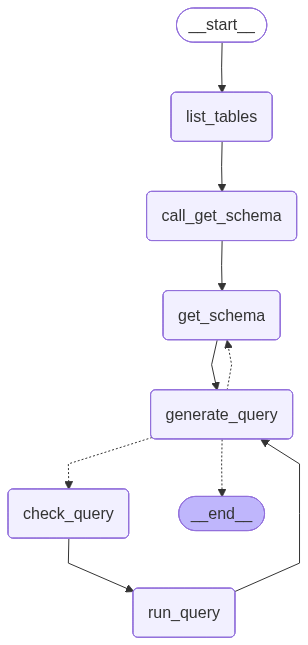

In [16]:
from IPython.display import Image, display

display(Image(sql_graph.get_graph().draw_mermaid_png()))

In [17]:
def format_messages_as_text(messages):
    lines = []

    for msg in messages:
        if isinstance(msg, dict):
            role = msg.get("role", "unknown")
            content = msg.get("content", "")
        else:
            msg_type = getattr(msg, "type", "unknown")
            content = getattr(msg, "content", "")

            if msg_type == "human":
                role = "user"
            elif msg_type == "ai":
                role = "assistant"
            else:
                role = msg_type

        lines.append(f"{role}: {content}")

    return "\n".join(lines)

def summarize(state: ParentState):
    
    messages = state.get("messages", [])
    latest_turn = messages[-2:] if len(messages) >= 2 else messages
    latest_turn_text = format_messages_as_text(latest_turn)
    old_summary = state.get("summary", "")
    
    summarize_prompt = f"""
    
        你是一个负责维护多轮对话记忆的模块。
        
        请基于【历史记忆】和【最新对话】，更新记忆。
        只保留对后续任务推进有价值的信息。
        
        记忆中只保留：
        - 用户当前目标
        - 已确认的关键信息
        - 用户偏好与限制
        - 尚未解决的问题
        - 下一步应做的事

        请遵守：
        - 不要复述原始对话
        - 不要保留寒暄、客套、重复内容
        - 若新旧信息冲突，以最新且明确确认的信息为准
        - 未确认内容单独标注，不要当作事实
        - 删除过时信息
        - 不要编造任何未出现的信息
        - 回答最多使用五句话，并保持简洁。

        【历史信息】
        {old_summary}

        【最新对话】
        {latest_turn_text}
        
    """
    
    summarize_history = llm.invoke([{"role": "user", "content": summarize_prompt}]).content.strip()
    
    print("-"*100)
    print("Summary")
    print(summarize_history)
    print("-"*100)
    
    return {
        "summary": summarize_history,
    }

In [19]:
class PlanDecision(BaseModel):
    route: Literal["sql", "rag", "clarify", "hybrid"]
    reason: str
    missing_slots: List[str] = Field(default_factory=list)
    tasks: List[SubTask] = Field(default_factory=list)

def plan_node(state: ParentState):
    question = state["real_query"]
    
    route_prompt = f"""
    
    你是一个上市公司财报智能问数系统的“任务规划器（Planner）”。

你的任务不是直接回答用户问题，而是：
1. 识别用户问题中包含的一个或多个核心意图；
2. 将问题拆解成可执行的子任务 tasks；
3. 为每个子任务指定：
   - task_id
   - type
   - goal
   - priority
   - depends_on
   - status
4. 输出一个可直接用于后续调度执行的计划。

你只能使用以下 task type：
- sql：适合结构化财务数据库查询，如指标、数值、同比、环比、趋势、排名、筛选、聚合、跨公司比较
- rag：适合非结构化文本检索，如原因解释、公告解读、研报观点、政策影响、风险分析、管理层表述
- clarify：当问题缺少关键条件，无法可靠执行时，用来向用户追问缺失信息
- synthesis：在多个前置任务完成后，对结果进行整合，输出统一答案

规划原则：
5. 若一个问题包含多个意图，必须拆成多个 tasks，而不是写成一个笼统任务
6. 任务之间若存在前后依赖，必须写入 depends_on
7. priority 数字越小越优先
8. status 初始一律设为 "pending"
9. 若 route = clarify，通常只输出一个 clarify task
10. 若存在多个执行任务，最后应包含一个 synthesis task，用于整合最终答案

槽位缺失判断：
- company：公司名
- period：时间范围/报告期
- metric：指标名
- compare_target：比较对象
- explanation_target：待解释对象（如“增长原因”中的增长指什么）

输出要求：
- 必须输出符合 schema 的 JSON
- 不要输出解释，不要输出思考过程，不要加 markdown 代码块
- tasks 中每个 task_id 必须唯一，如 task_1, task_2, task_3
- depends_on 里只能引用已出现过的 task_id

示例1
用户问题：比亚迪2025年三季度营业收入是多少？
输出：
{{
  "reason": "这是明确的单指标单时期数值查询，主要依赖结构化财务数据库",
  "missing_slots": [],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "sql",
      "goal": "查询比亚迪2025年三季度营业收入",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

示例2
用户问题：华润三九近三年的主营业务收入情况做可视化绘图，主营业务收入上升的原因是什么？
输出：
{{
  "reason": "该问题既需要结构化财务数据做趋势分析，也需要非结构化文本解释收入上升原因",
  "missing_slots": [],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "sql",
      "goal": "查询华润三九近三年主营业务收入的时间序列数据，并用于可视化绘图",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }},
    {{
      "task_id": "task_2",
      "type": "rag",
      "goal": "检索华润三九主营业务收入上升原因的公告、年报或研报证据",
      "priority": 2,
      "depends_on": ["task_1"],
      "status": "pending"
    }},
    {{
      "task_id": "task_3",
      "type": "synthesis",
      "goal": "整合主营业务收入趋势结果与原因解释，形成统一答复",
      "priority": 3,
      "depends_on": ["task_1", "task_2"],
      "status": "pending"
    }}
  ]
}}

示例3
用户问题：利润总额是多少？
输出：
{{
  "reason": "问题缺少公司和报告期，无法可靠执行查询",
  "missing_slots": ["company", "period"],
  "tasks": [
    {{
      "task_id": "task_1",
      "type": "clarify",
      "goal": "向用户确认公司名称和报告期，以继续查询利润总额",
      "priority": 1,
      "depends_on": [],
      "status": "pending"
    }}
  ]
}}

现在请对下面这个用户问题生成计划：
用户问题：{question}
""".strip()
    
    structured_llm = llm.with_structured_output(PlanDecision)
    decision = structured_llm.invoke(route_prompt)
    
    return {
        "real_query": question,
        "route": decision.route,
        "reason": decision.reason,
        "missing_slots": decision.missing_slots,
        "task_plan": [task.model_dump() for task in decision.tasks],
        "current_task_id": "",
    }

In [20]:
def get_current_task(state: ParentState):
    task_id = state["current_task_id"]
    for task in state.get("task_plan", []):
        if task_id == task["task_id"]:
            return task_id
    raise ValueError(f"找不到当前任务:{task_id}")

In [21]:
def rag_node(state: ParentState):
    task = get_current_task(state)
    goal = task["goal"]
    
    docs = retriever.invoke(goal)

    docs_text = "\n\n".join([doc.page_content for doc in docs])

    return {
        "task_results": {
            task["task_id"]: {
                "type": "rag",
                "goal": goal,
                "docs": docs,
                "docs_text": docs_text,
            }
        },
        "execution_trace": [{
            "task_id": task["task_id"],
            "type": "rag",
            "goal": goal,
            "status": "done"
        }]
    }

In [22]:
def clarify(state: ParentState):
    question = state["real_query"]
    missing_slots = state.get("missing_slots", [])

    clarify_prompt = f"""
        你是一个上市公司财报智能问数助手。

        用户原始问题：
        {question}

        当前还缺少这些关键信息：
        {missing_slots}

        你的任务是：
        基于用户原始问题和缺失槽位，生成一句自然、简洁、礼貌的澄清问题，引导用户一次性补全所缺信息，以便继续查询。

        要求：
        1. 只输出一句面向用户的澄清问题，不要输出解释，不要输出 JSON，不要输出多余内容。
        2. 如果缺少多个槽位，尽量合并成一句话一起问，不要拆成多句。
        3. 语气自然，适合中文对话场景。
        4. 问法要贴合财报问数场景。
        
        示例1
        原始问题：利润总额是多少？
        缺失槽位：["company", "period"]
        输出：请问你想查询哪家公司，以及哪个报告期的利润总额？

        示例2
        原始问题：同比最高的是哪家？
        缺失槽位：["metric", "period", "ranking_scope"]
        输出：请问你想查询哪个指标、哪个报告期，以及希望在哪个范围内比较同比？

        示例3
        原始问题：原因是什么？
        缺失槽位：["explanation_target"]
        输出：请问你具体想了解哪个指标或现象变化的原因？
        """.strip()

    response = llm.invoke([{"role": "user", "content": clarify_prompt}])

    return {
        "messages": [AIMessage(content=response.content)],
        "final_answer": response.content,
        "missing_slots": missing_slots,
    }

In [23]:
def merge_generate(state: ParentState):
    question = state["real_query"]
    task_results = state.get("task_results", {})

    sql_parts = []
    rag_parts = []
    images = []

    for task_id, result in task_results.items():
        if result.get("type") == "sql":
            sql_parts.append(f"[{task_id}] {result.get('goal','')}\n{result.get('answer','')}")
            images.extend(result.get("image_path", []))
        elif result.get("type") == "rag":
            rag_parts.append(f"[{task_id}] {result.get('goal','')}\n{result.get('docs_text','')}")

    prompt = f"""
你是一个财报智能助手。请根据已经完成的子任务结果，形成统一、连贯、去重后的最终回答。

用户问题：
{question}

SQL子任务结果：
{chr(10).join(sql_parts) if sql_parts else "无"}

RAG子任务结果：
{chr(10).join(rag_parts) if rag_parts else "无"}

要求：
1. 若有 SQL 结果，优先作为事实依据
2. 若有 RAG 结果，用来补充背景、解释和原因
3. 不要编造未执行得到的信息
4. 回答简洁、自然
"""

    response = llm.invoke([{"role": "user", "content": prompt}])

    return {
        "messages": [response],
        "final_answer": response.content,
        "image_path": images
    }

In [38]:
def scheduler(state: ParentState):
    task_plan = state.get("task_plan", [])
    task_results = state.get("task_results", {})
    
    updated_plan = []
    ready_tasks = []
    
    for task in task_plan:
        t = dict(task)
        
        if t["status"] in ["done", "failed"]:
            updated_plan.append(t)
            continue

        if all_deps_done(t, task_results):
            if t["status"] == "pending":
                t["status"] = "ready"

        if t["status"] == "ready":
            ready_tasks.append(t)

        updated_plan.append(t)

    if not ready_tasks:
        return {
            "task_plan": updated_plan,
            "current_task_id": "",
        }

    ready_tasks.sort(key=lambda x: (x["priority"], x["task_id"]))
    current = ready_tasks[0]

    updated_plan = update_task_status(updated_plan, current["task_id"], "running")

    return {
        "task_plan": updated_plan,
        "current_task_id": current["task_id"],
    }

def scheduler_route(state: ParentState) -> Literal["sql_node", "rag_node", "clarify", "merge_generate"]:
    task_id = state.get("current_task_id", "")
    if not task_id:
        return "merge_generate"
    
    task = get_current_task(state)
    t = task["type"]
    
    if t == "sql":
        return "sql_node"
    if t == "rag":
        return "rag_node"
    if t == "clarify":
        return "clarify"
    if t == "synthesis":
        return "merge_generate"

    raise ValueError(f"未知任务类型: {t}")

In [39]:
import os
import re
import uuid
import pandas as pd
import matplotlib.pyplot as plt
from langgraph.checkpoint.memory import MemorySaver

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("./result", exist_ok=True)

PLOT_KEYWORDS = [
    "趋势", "走势", "变化", "可视化", "绘图", "画图",
    "折线图", "柱状图", "历年", "近年", "近三年", "近五年"
]

def should_plot(question: str) -> bool:
    return any(k in question for k in PLOT_KEYWORDS)

def extract_last_sql_query(messages):
    for msg in reversed(messages):
        tool_calls = getattr(msg, "tool_calls", None) or []
        for tc in tool_calls:
            if tc.get("name") == "sql_db_query":
                args = tc.get("args", {}) or {}
                sql_text = args if isinstance(args, str) else (
                    args.get("query") or
                    args.get("__arg1") or
                    args.get("input") or
                    args.get("sql")
                )
                if sql_text:
                    return sql_text
    return None

def period_sort_key(val):
    s = str(val).strip()
    m = re.match(r"(\d{4})(?:Q([1-4])|FY)", s)
    if not m:
        return (9999, 99, s)

    year = int(m.group(1))
    order = 5 if "FY" in s else int(m.group(2))
    return (year, order, s)

def pick_xy_columns(df):
    """
    自动找 x 轴和 y 轴：
    优先找 x_axis / y_axis，
    否则优先 report_period + 第一个可转成数值的列
    """
    x_candidates = ["x_axis", "report_period", "period", "日期", "年份", "year"]
    x_col = next((c for c in x_candidates if c in df.columns), df.columns[0])

    numeric_cols = []
    for c in df.columns:
        if c == x_col:
            continue
        series = pd.to_numeric(df[c], errors="coerce")
        if series.notna().any():
            numeric_cols.append(c)

    if not numeric_cols:
        raise ValueError(f"没有找到可绘图的数值列，当前列为: {list(df.columns)}")

    y_col = "y_axis" if "y_axis" in numeric_cols else numeric_cols[0]
    return x_col, y_col

def save_line_chart(df, question, out_dir="./result", prefix="chart"):
    if df is None or df.empty or len(df.columns) < 2:
        return []

    x_col, y_col = pick_xy_columns(df)

    plot_df = df[[x_col, y_col]].copy()
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[y_col])

    if plot_df.empty or len(plot_df) < 2:
        return []

    if x_col in ["x_axis", "report_period", "period"]:
        plot_df["_sort_key"] = plot_df[x_col].map(period_sort_key)
        plot_df = plot_df.sort_values("_sort_key").drop(columns=["_sort_key"])

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(plot_df[x_col].astype(str), plot_df[y_col], marker="o")
    ax.set_title(question)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.xticks(rotation=45)
    plt.tight_layout()

    os.makedirs(out_dir, exist_ok=True)
    file_path = os.path.join(out_dir, f"{prefix}_{uuid.uuid4().hex[:8]}.png")
    plt.savefig(file_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    return [file_path]

In [40]:
def sql_node(state: ParentState):
    question = state["real_query"]

    result = sql_graph.invoke({
        "sql_messages": [{"role": "user", "content": question}],
        "real_query": question,
    })

    sql_messages = result["sql_messages"]
    last_msg = sql_messages[-1]
    answer = getattr(last_msg, "content", str(last_msg))

    sql_text = extract_last_sql_query(sql_messages)
    image_paths = []

    if sql_text and should_plot(question):
        try:
            df = pd.read_sql_query(sql_text, engine)
            image_paths = save_line_chart(
                df,
                question,
                out_dir="./result",
                prefix="sql_plot"
            )
        except Exception as e:
            print(f"[plot error] {e}")

    return {
        "messages": [last_msg],
        "task_results": {
            task["task_id"]: {
                "type": "sql",
                "goal": goal,
                "query": sql_text,
                "answer": answer,
                "image_path": image_paths,
            }
        },
        "execution_trace": [{
            "task_id": task["task_id"],
            "type": "sql",
            "goal": goal,
            "status": "done"
        }]
    }

In [41]:
def mark_current_task_done(state: ParentState):
    task_id = state["current_task_id"]
    new_plan = update_task_status(state["task_plan"], task_id, "done")

    return {
        "task_plan": new_plan
    }

In [42]:
workflow = StateGraph(ParentState)

workflow.add_node("sql_node", sql_node) 
workflow.add_node("rag_node", rag_node) 
workflow.add_node("plan_node", plan_node) 
workflow.add_node("clarify", clarify)
workflow.add_node("merge_generate", merge_generate)
workflow.add_node("real_query", merge_query)
workflow.add_node("summarize", summarize)
workflow.add_node("scheduler", scheduler)
workflow.add_node("mark_current_task_done", mark_current_task_done)

workflow.add_edge(START, "real_query")

workflow.add_edge("real_query", "plan_node")
workflow.add_edge("plan_node", "scheduler")

workflow.add_conditional_edges(
    "scheduler",
    scheduler_route,
#     {
#         "sql_node": "sql_node",
#         "rag_node": "rag_node",
#         "clarify": "clarify",
#         "merge_generate": "merge_generate",
#     },
)

workflow.add_edge("sql_node", "mark_current_task_done")
workflow.add_edge("rag_node", "mark_current_task_done")
workflow.add_edge("mark_current_task_done", "scheduler")

workflow.add_edge("clarify", "summarize")
workflow.add_edge("merge_generate", "summarize")

workflow.add_edge("summarize", END)

checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

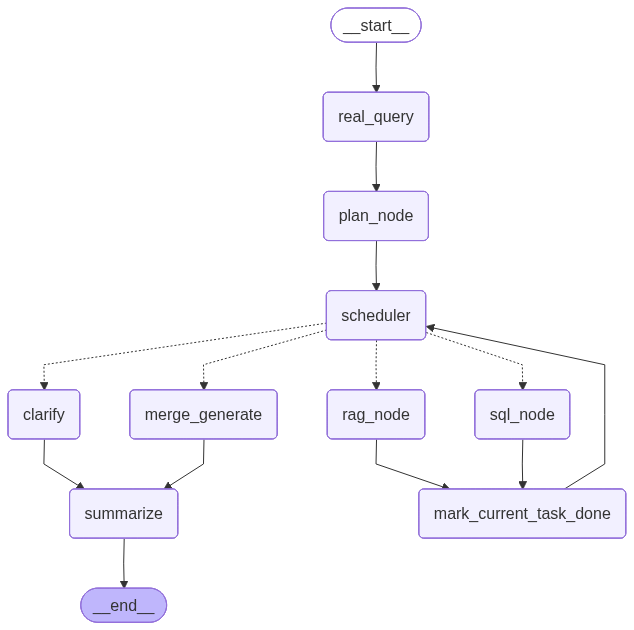

In [44]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
from pprint import pprint

def format_msg(msg):
    if isinstance(msg, dict):
        role = msg.get("role", "unknown")
        content = msg.get("content", "")
        return f"{role}: {content}"

    msg_type = getattr(msg, "type", msg.__class__.__name__)
    content = getattr(msg, "content", str(msg))

    if msg_type == "human":
        role = "user"
    elif msg_type == "ai":
        role = "assistant"
    else:
        role = msg_type

    return f"{role}: {content}"


def run_test_case(user_query: str, thread_id: str = "test1"):
    inputs = {
        "messages": [
            {
                "role": "user",
                "content": user_query,
            }
        ],
        "query": user_query,
    }

    config = {"configurable": {"thread_id": thread_id}}

    print("=" * 100)
    print(f"用户问题: {user_query}")
    print(f"thread_id: {thread_id}")
    print("=" * 100)

    for step in graph.stream(inputs, config):
        for node_name, node_output in step.items():
            print(f"\nNode: {node_name}")

            if not isinstance(node_output, dict):
                print(node_output)
                continue

            # 1. messages
            if "messages" in node_output and node_output["messages"]:
                print("messages:")
                print(format_msg(node_output["messages"][-1]))

            # 2. real_query
            if "real_query" in node_output:
                print("real_query:")
                print(node_output["real_query"])

            # 3. route / missing_slots
            if "route" in node_output:
                print("route:")
                print(node_output["route"])

            if "missing_slots" in node_output:
                print("missing_slots:")
                pprint(node_output["missing_slots"])

            # 4. task_plan
            if "task_plan" in node_output:
                print("task_plan:")
                pprint(node_output["task_plan"])

            # 5. current_task_id
            if "current_task_id" in node_output:
                print("current_task_id:")
                print(node_output["current_task_id"])

            # 6. task_results
            if "task_results" in node_output:
                print("task_results:")
                pprint(node_output["task_results"])

            # 7. execution_trace
            if "execution_trace" in node_output:
                print("execution_trace:")
                pprint(node_output["execution_trace"])

            # 8. final_answer
            if "final_answer" in node_output:
                print("final_answer:")
                print(node_output["final_answer"])

            # 9. image_path
            if "image_path" in node_output:
                print("image_path:")
                pprint(node_output["image_path"])

            # 10. summary
            if "summary" in node_output:
                print("summary:")
                print(node_output["summary"])

        print("-" * 100)

In [43]:
run_test_case("华润三九每股收益是多少", thread_id="test10")

用户问题: 华润三九每股收益是多少
thread_id: test10

Node: real_query
real_query:
华润三九每股收益是多少
----------------------------------------------------------------------------------------------------

Node: plan_node
real_query:
华润三九每股收益是多少
route:
clarify
missing_slots:
['period']
----------------------------------------------------------------------------------------------------

Node: scheduler
None
----------------------------------------------------------------------------------------------------

Node: merge_generate
messages:
assistant: 抱歉，根据目前的查询结果，未能获取到华润三九的每股收益相关信息。请确认查询的具体时间范围或稍后再试。
final_answer:
抱歉，根据目前的查询结果，未能获取到华润三九的每股收益相关信息。请确认查询的具体时间范围或稍后再试。
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Summary
用户当前目标是查询华润三九的每股收益。目前系统未能获取到相关数据，该问题尚未解决。下一步需等待用户确认具体时间范围或重新尝试查询。
--------------------------------------------------------------------------------

In [22]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "金花股份利润总额是多少",
        }
    ],
    "query": "金花股份利润总额是多少",
}

print("=" * 100)

config = {"configurable": {"thread_id": "test1"}}

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 100)

Node 'real_query':
{'real_query': '金花股份利润总额是多少'}
----------------------------------------------------------------------------------------------------
Node 'route_node':
{'real_query': '金花股份利润总额是多少', 'route': 'clarify', 'reason': '缺少报告期，无法直接执行查询', 'missing_slots': ['period'], 'subtasks': [], 'need_sql': False, 'need_rag': False, 'need_clarification': True, 'final_answer': ''}
----------------------------------------------------------------------------------------------------
Node 'clarify':
content='请问您想查询金花股份哪个报告期的利润总额？' additional_kwargs={} response_metadata={} id='5f42ffba-112e-4bd8-800e-676a983f8c20' tool_calls=[] invalid_tool_calls=[]
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Summary
用户当前目标是查询金花股份的利润总额。目前尚未确认具体的报告期。下一步需等待用户提供报告期信息。
----------------------------------------------------------------------------------------------

In [23]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "华润三九2023第一季度的每股收益是多少",
        }
    ],
    "query": "华润三九2023第一季度的每股收益是多少",
}

print("=" * 50)

config = {"configurable": {"thread_id": "test2"}}

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 50)

Node 'real_query':
{'real_query': '华润三九2023第一季度的每股收益是多少'}
--------------------------------------------------
Node 'route_node':
{'real_query': '华润三九2023第一季度的每股收益是多少', 'route': 'sql', 'reason': '这是明确的单指标单时期数值查询，可直接通过结构化财务数据库回答', 'missing_slots': [], 'subtasks': [{'type': 'sql', 'goal': '查询华润三九2023第一季度的每股收益'}], 'need_sql': True, 'need_rag': False, 'need_clarification': False, 'final_answer': ''}
--------------------------------------------------
Node 'sql_node':
content='根据查询结果，**华润三九2023年第一季度的每股收益是1.16元**。\n\n该数据来源于华润三九的2023年一季度报告。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 2430, 'total_tokens': 2509, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 42, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 2193}}, 'model_provider': 'openai', 'model_name': 'glm-5', 'system_fingerprint': None, 'id': 'chatcmpl-cfc3

In [24]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "华润三九近几年的每股收益的变化趋势",
        }
    ],
    "query": "华润三九近几年的每股收益的变化趋势",
}

print("=" * 50)

config = {"configurable": {"thread_id": "test3"}}

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 50)

Node 'real_query':
{'real_query': '华润三九近几年的每股收益的变化趋势'}
--------------------------------------------------
Node 'route_node':
{'real_query': '华润三九近几年的每股收益的变化趋势', 'route': 'sql', 'reason': '这是特定财务指标的时间序列趋势查询，主要依赖结构化财务数据', 'missing_slots': [], 'subtasks': [{'type': 'sql', 'goal': '查询华润三九近几年的每股收益并展示变化趋势'}], 'need_sql': True, 'need_rag': False, 'need_clarification': False, 'final_answer': ''}
--------------------------------------------------
Node 'sql_node':
content='根据查询结果，华润三九近几年的每股收益（EPS）变化趋势如下：\n\n| 年份 | 每股收益（元） |\n|------|----------------|\n| 2022 | 2.48 |\n| 2023 | 2.90 |\n| 2024 | 2.63 |\n\n**趋势分析：**\n- 2022年至2023年：每股收益从2.48元增长至2.90元，增幅约17%，呈现上升趋势\n- 2023年至2024年：每股收益从2.90元下降至2.63元，降幅约9%，出现回落\n\n总体来看，华润三九的每股收益在近三年呈现先升后降的波动趋势，2023年达到相对高点后，2024年有所回调。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 255, 'prompt_tokens': 2446, 'total_tokens': 2701, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoni

In [22]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "国家医保目录新增的中药产品有哪些",
        }
    ],
    "query": "国家医保目录新增的中药产品有哪些",
}

print("=" * 100)

config = {"configurable": {"thread_id": "test4"}}

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 100)

Node 'real_query':
{'real_query': '国家医保目录新增的中药产品有哪些'}
----------------------------------------------------------------------------------------------------
Node 'route_node':
{'real_query': '国家医保目录新增的中药产品有哪些', 'route': 'rag', 'reason': '这是知识检索类问题，需要依赖政策或研报等非结构化文本知识库', 'missing_slots': [], 'subtasks': [{'type': 'rag', 'goal': '检索医保目录与相关研报中新增中药产品信息'}], 'need_sql': False, 'need_rag': True, 'need_clarification': False, 'final_answer': ''}
----------------------------------------------------------------------------------------------------
Node 'rag_node':
{'rag_result': {'used': True, 'success': True, 'question': '国家医保目录新增的中药产品有哪些', 'docs': [Document(metadata={'moddate': '2025-12-08T15:50:06+08:00', 'creationDate': '', 'producer': 'Aspose.PDF for .NET 19.1; modified using iTextSharp 5.2.1 (c) 1T3XT BVBA', 'trapped': '', 'title': '国金证券-医药健康行业研究：从2025医保谈判看行业风向，成功率提升，创新导向持续强化-251207.pdf', 'keywords': '', 'author': '', 'creationdate': '', 'modDate': "D:20251208155006+08'00'", 'subject': '', 'pag

----------------------------------------------------------------------------------------------------
Summary
用户当前目标：查询2025年国家医保目录新增中药产品。
已确认关键信息：2025年新增7个中药产品，均为独家品种；具体包括益气清肺颗粒、芪防鼻通片、养血祛风止痛颗粒、玉女煎颗粒及温阳解毒颗粒。
下一步：等待用户进一步指令。
----------------------------------------------------------------------------------------------------
Node 'summarize':
{'summary': '用户当前目标：查询2025年国家医保目录新增中药产品。\n已确认关键信息：2025年新增7个中药产品，均为独家品种；具体包括益气清肺颗粒、芪防鼻通片、养血祛风止痛颗粒、玉女煎颗粒及温阳解毒颗粒。\n下一步：等待用户进一步指令。'}
----------------------------------------------------------------------------------------------------


In [26]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "华润三九每股收益是多少",
        }
    ],
    "query": "华润三九每股收益是多少",
}

print("=" * 100)

config = {"configurable": {"thread_id": "clarify-demo-thread"}}

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 100)
    
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "2023年一季度的",
        }
    ],
    "query": "2023年一季度的",
}

print("=" * 100)

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 100)

Node 'real_query':
{'real_query': '华润三九每股收益是多少'}
----------------------------------------------------------------------------------------------------
Node 'route_node':
{'real_query': '华润三九每股收益是多少', 'route': 'clarify', 'reason': '缺少报告期，无法直接执行查询', 'missing_slots': ['period'], 'subtasks': [], 'need_sql': False, 'need_rag': False, 'need_clarification': True, 'final_answer': ''}
----------------------------------------------------------------------------------------------------
Node 'clarify':
content='请问您想查询华润三九哪个报告期的每股收益？' additional_kwargs={} response_metadata={} id='cf3c29be-1dc3-4a79-b06a-de6c0903c24f' tool_calls=[] invalid_tool_calls=[]
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Summary
用户当前目标是查询华润三九的每股收益。已确认查询对象为华润三九，指标为每股收益。尚未解决的问题是用户未指定报告期。下一步需等待用户提供具体的报告期信息。
------------------------------------------------------------------

In [23]:
inputs = {
    "messages": [
        {
            "role": "user",
            "content": "2024 年利润最高的 top10 企业是哪些？这些企业的利润、销售额年同比是多少？年同比上涨幅度最大的是哪家企业？",
        }
    ],
    "query": "2024 年利润最高的 top10 企业是哪些？这些企业的利润、销售额年同比是多少？年同比上涨幅度最大的是哪家企业？",
}

print("=" * 100)

config = {"configurable": {"thread_id": "test5"}}

for output in graph.stream(inputs, config):
    for key, value in output.items():
        print(f"Node '{key}':")
        if isinstance(value, dict) and "messages" in value:
            print(value["messages"][-1])
        else:
            print(value)
    print("-" * 100)

Node 'real_query':
{'real_query': '2024 年利润最高的 top10 企业是哪些？这些企业的利润、销售额年同比是多少？年同比上涨幅度最大的是哪家企业？'}
----------------------------------------------------------------------------------------------------
Node 'route_node':
{'real_query': '2024 年利润最高的 top10 企业是哪些？这些企业的利润、销售额年同比是多少？年同比上涨幅度最大的是哪家企业？', 'route': 'sql', 'reason': '问题包含排名查询（top10）、数值计算（年同比）和比较筛选（上涨幅度最大），均属于典型的结构化数据查询与统计范畴', 'missing_slots': [], 'subtasks': [{'type': 'sql', 'goal': '查询2024年利润最高的top10企业名单'}, {'type': 'sql', 'goal': '计算这些企业的利润和销售额年同比'}, {'type': 'sql', 'goal': '筛选出年同比上涨幅度最大的企业'}], 'need_sql': True, 'need_rag': False, 'need_clarification': False, 'final_answer': ''}
----------------------------------------------------------------------------------------------------
Node 'sql_node':
content='根据数据库查询结果，我来为您解答：\n\n## 2024年利润最高的企业情况\n\n**重要说明：** 数据库中目前只有**华润三九**这一家企业的2024年数据，因此无法提供完整的top10排名。以下是华润三九2024年的详细数据：\n\n### 华润三九2024年各报告期数据：\n\n| 报告期 | 净利润（元） | 利润年同比 | 营业收入（元） | 营收年同比 |\n|--------|-------------|-----------|--------